In [70]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
from matplotlib.ticker import FormatStrFormatter
from matplotlib.collections import LineCollection
import importlib
import scipy.linalg
sys.path.append('..')

# Now Python can see the 'src' folder!
import src.R2FMath as R2FMath
importlib.reload(R2FMath)

<module 'src.R2FMath' from 'c:\\python\\CeramicCap3\\analysis\\..\\src\\R2FMath.py'>

In [ ]:
#bd = r'U:\012 - CeramicCap\CAPDATA\2519J00896'
#fn ='VOLT_10nF-1nF_20260224_1146.dat' #VOLT_10nF-1nF_20260202_1454.dat'
bd = r'U:\012 - CeramicCap\CAPDATA\2519J00213'
data = np.loadtxt(os.path.join(bd,fn))
ave = 0.5*(data[0:-1:2,:]+data[1::2,:])

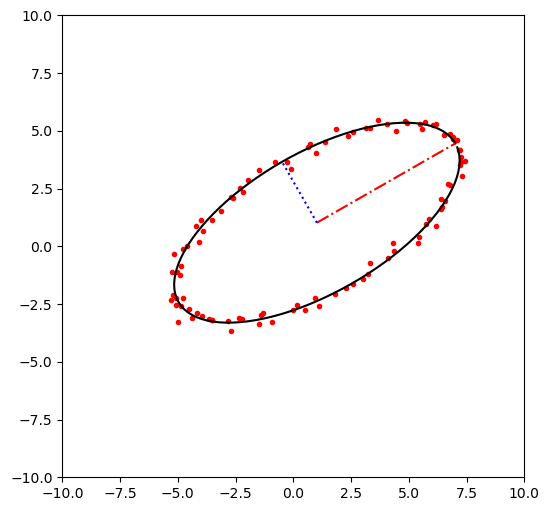

In [145]:
true_ellipse = R2FMath.ComplexEllipse(eta_o=1+1j, eta_ccw=5*np.exp(1j*30/180*np.pi), eta_cw=2*np.exp(1j*30/180*np.pi))

# Simulate what the R2F converter would actually see
x_noisy, y_noisy = true_ellipse.simulate_noisy_data(N=100, noise_std=0.2)

# Test your fitting algorithm
fitted_ellipse = R2FMath.ComplexEllipse.fit_from_points(x_noisy, y_noisy)
#fitted_cplx = fitted_ellipse.evaluate()

fig,ax = plt.subplots(1,figsize=(6,6))
ax.plot(x_noisy, y_noisy,'r.')

fitted_ellipse.plot_elli(ax)
#ax.plot(np.real(fitted_cplx), np.imag(fitted_cplx),'b-')
ax.set_xlim(-10, 10)
ax.set_ylim(-10, 10)
ax.set_aspect('equal')
#ax.set_aspect('equal', adjustable='box')
#plt.tight_layout()


In [146]:
be =0
en = be+8
eta2 =  1000*(ave[be:en,4]+1j*ave[be:en,5])/(ave[be:en,2]+1j*ave[be:en,3])
eta3 =  1000*(ave[be:en,6]+1j*ave[be:en,7])/(ave[be:en,2]+1j*ave[be:en,3])
eta4 =  1000*(ave[be:en,8]+1j*ave[be:en,9])/(ave[be:en,2]+1j*ave[be:en,3])

elli2 = fitted_ellipse = R2FMath.ComplexEllipse.fit_from_cmplx_points(eta2)
elli3 = fitted_ellipse = R2FMath.ComplexEllipse.fit_from_cmplx_points(eta3)
elli4 = fitted_ellipse = R2FMath.ComplexEllipse.fit_from_cmplx_points(eta4)

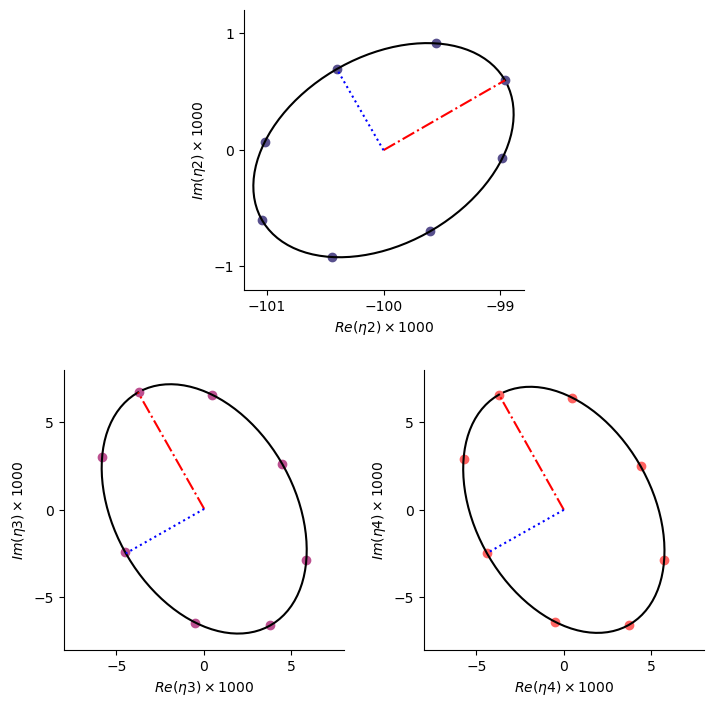

In [147]:
co1='#003f5c'
co2='#444e86'
co3='#955196'
co4='#dd5182'
co1='#58508d'
co2='#bc5090'
co3='#ff6361'
co4='#ffa600'
fig = plt.figure(figsize=(8, 8))
ax = []
w = 0.35  # Plot width
h = 0.35  # Plot height
dh = 0.1  # Vertical gap
dw = 0.1  # Horizontal gap
center_x = 0.5 - (w / 2)
ax.append(fig.add_axes((center_x, 0.1 + h + dh, w, h)))
ax.append(fig.add_axes((0.5 - w - dw/2, 0.1, w, h)))
ax.append(fig.add_axes((0.5 + dw/2, 0.1, w, h)))
ax[0].plot(np.real(eta2),np.imag(eta2),marker='o',c=co1,linestyle='None')
ax[1].plot(np.real(eta3),np.imag(eta3),marker='o',c=co2,linestyle='None')
ax[2].plot(np.real(eta4),np.imag(eta4),marker='o',c=co3,linestyle='None')
elli2.plot_elli(ax[0])
elli3.plot_elli(ax[1])
elli4.plot_elli(ax[2])

ax[0].set_xlim(-101.2,-98.8)
ax[0].set_ylim(-1.2,1.2)
ax[1].set_xlim(-8,8)
ax[1].set_ylim(-8,8)

ax[2].set_xlim(-8,8)
ax[2].set_ylim(-8,8)

ax[0].set_xticks([-101,-100,-99])
ax[0].set_yticks([-1,0,1])
ax[1].set_yticks([-5,0,5])
ax[2].set_yticks([-5,0,5])

for n,axs in enumerate(ax):
    axs.spines['top'].set_visible(False)
    axs.spines['right'].set_visible(False)
    axs.set_xlabel(f'$Re(\eta{n+2})'+r'\times 1000$')
    axs.set_ylabel(f'$Im(\eta{n+2})'+r'\times 1000$')
    axs.ticklabel_format(useOffset=False)

fig.savefig('ellipses.pdf',bbox_inches='tight', 
               transparent=True,
               pad_inches=0)

In [148]:
gain3 = (elli3.eta_cw/elli2.eta_cw+elli3.eta_ccw/elli2.eta_ccw)/2
gain4 = (elli4.eta_cw/elli2.eta_cw+elli4.eta_ccw/elli2.eta_ccw)/2


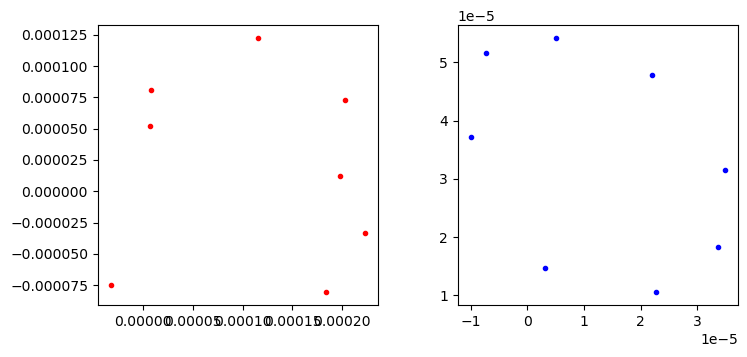

In [149]:
fig = plt.figure(figsize=(8, 8))
ax = []

w = 0.35  # Plot width
h = 0.35  # Plot height
dh = 0.1  # Vertical gap
dw = 0.1  # Horizontal gap

# Calculate the center for the top plot
# (0.5 - half the plot width) centers it exactly
center_x = 0.5 - (w / 2)

# 2. Bottom Left
ax.append(fig.add_axes((0.5 - w - dw/2, 0.1, w, h)))

# 3. Bottom Right

ax.append(fig.add_axes((0.5 + dw/2, 0.1, w, h)))
ax[0].plot(np.real(-eta2+eta3/gain3)/1000*10-1,np.imag(-eta2+eta3/gain3)/1000*10,'r.')
ax[1].plot(np.real(-eta2+eta4/gain4)/1000*10-1,np.imag(-eta2+eta4/gain4)/1000*10,'b.')
ax[0].ticklabel_format(useOffset=False)




In [150]:
output=[]
for i in range(0, len(ave), 8):
    block = ave[i : i + 8,:]
    if len(block) < 8:
        print(f"Processing final partial block of size {len(block)}")
        break
    f = np.mean(block[:,0])
    eta2 =  1000*(block[:,4]+1j*block[:,5])/(block[:,2]+1j*block[:,3])
    eta3 =  1000*(block[:,6]+1j*block[:,7])/(block[:,2]+1j*block[:,3])
    eta4 =  1000*(block[:,8]+1j*block[:,9])/(block[:,2]+1j*block[:,3])

    elli2 = fitted_ellipse = R2FMath.ComplexEllipse.fit_from_cmplx_points(eta2)
    elli3 = fitted_ellipse = R2FMath.ComplexEllipse.fit_from_cmplx_points(eta3)
    elli4 = fitted_ellipse = R2FMath.ComplexEllipse.fit_from_cmplx_points(eta4)    
    gain3 = (elli3.eta_cw/elli2.eta_cw+elli3.eta_ccw/elli2.eta_ccw)/2
    gain4 = (elli4.eta_cw/elli2.eta_cw+elli4.eta_ccw/elli2.eta_ccw)/2
    
    alpha3 = np.mean(np.real(-eta2+eta3/gain3)/1000*10-1)
    beta3  = np.mean(np.imag(-eta2+eta3/gain3)/1000*10)
    alpha4 = np.mean(np.real(-eta2+eta4/gain4)/1000*10-1)
    beta4  = np.mean(np.imag(-eta2+eta4/gain4)/1000*10)
    line = np.hstack((f, np.abs(gain3), np.abs(gain4), alpha3,beta3, alpha4,beta4))
    output.append(line)
output= np.array(output)





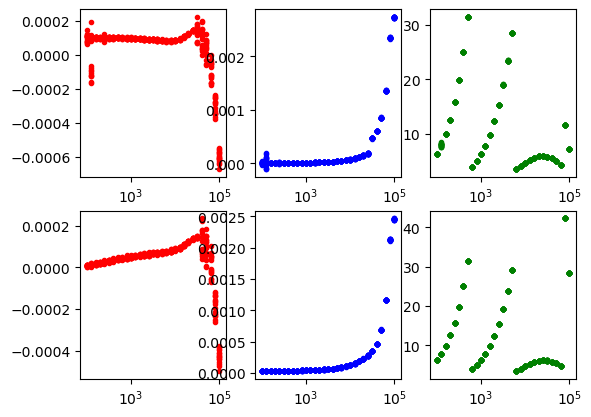

In [179]:
fig,ax = plt.subplots(2,3)
ax = ax.flatten()
ax[0].plot(output[:,0],output[:,3],'r.')   #alpha3
ax[1].plot(output[:,0],output[:,4],'b.')   #beta3
ax[2].plot(output[:,0],output[:,1],'g.')   #gain3
ax[3].plot(output[:,0],output[:,5],'r.')   #alpha4
ax[4].plot(output[:,0],output[:,6],'b.')   #beta4
ax[5].plot(output[:,0],output[:,2],'g.')   #gain4

for a in ax:
    a.set_xscale('log')

In [159]:
data_ana =  np.loadtxt(os.path.join(bd,'CC3_10nF-1nF_20260224_1146.dat'))

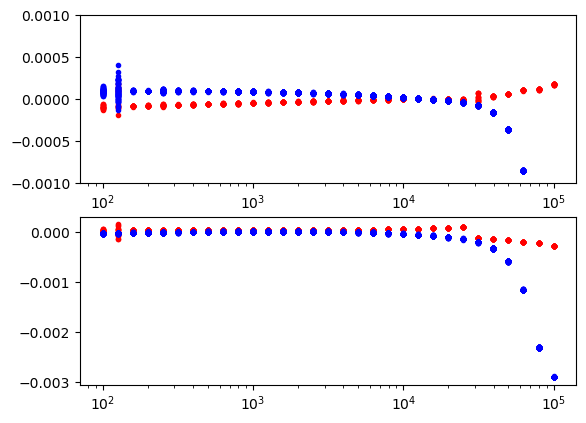

In [169]:
fig,ax = plt.subplots(2)
ax = ax.flatten()
ax[0].plot(output[:,0],output[:,5]-output[:,3],'r.')
ax[1].plot(output[:,0],output[:,6]-output[:,4],'r.')
ax[0].plot(data_ana[:,0],data_ana[:,3]-data_ana[:,2],'b.')
ax[1].plot(data_ana[:,0],data_ana[:,5]-data_ana[:,4],'b.')
#ax[0].set_xlim(100,10000)
ax[0].set_ylim(-1e-3,1e-3)

ax[0].set_xscale('log')
ax[1].set_xscale('log')



In [117]:
output[1,0]

TypeError: list indices must be integers or slices, not tuple